# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy



### Dataset: African Economic Activity & Population Pressure
This dataset contains 7 socioeconomic indicators for 30 African countries, drawn from World Bank estimates. The features capture **economic activity** (GDP per capita, electricity access, literacy rate) and **population pressure** (population growth rate, urbanisation rate, agricultural land use, life expectancy).

In [1]:
import numpy as np

# African countries
country_names = [
    'Nigeria', 'Ethiopia', 'South Africa', 'Egypt', 'Kenya',
    'Ghana', 'Tanzania', 'Morocco', 'Algeria', 'Sudan',
    'Angola', 'Mozambique', 'Uganda', 'Cameroon', 'Ivory Coast',
    'Zimbabwe', 'Zambia', 'Senegal', 'Tunisia', 'Rwanda',
    'Mali', 'Niger', 'Burkina Faso', 'Guinea', 'Benin',
    'Madagascar', 'Malawi', 'Botswana', 'Namibia', 'Gabon'
]

# Features (columns):
# [GDP_per_capita(USD), Pop_growth_rate(%), Urban_pop(%), Agri_land(%),
#  Life_expectancy(yrs), Literacy_rate(%), Electricity_access(%)]
feature_names = [
    'GDP_per_capita', 'Pop_growth_rate', 'Urban_pop_pct',
    'Agri_land_pct', 'Life_expectancy', 'Literacy_rate', 'Electricity_access'
]

data = np.array([
    [2085,  2.55, 52.0, 78.0, 54.3, 62.0, 55.4],   # Nigeria
    [ 936,  2.57, 22.0, 34.3, 65.5, 51.8, 44.3],   # Ethiopia
    [6527,  1.37, 68.0, 79.7, 63.9, 95.0, 84.0],   # South Africa
    [3548,  1.94, 43.0, 56.0, 71.8, 75.2,100.0],   # Egypt
    [2094,  2.29, 28.0, 67.6, 66.7, 81.5, 75.0],   # Kenya
    [2202,  2.17, 58.0, 69.1, 64.1, 79.0, 79.3],   # Ghana
    [1083,  2.96, 36.0, 39.5, 65.5, 77.9, 38.0],   # Tanzania
    [3204,  1.20, 64.0, 66.7, 76.7, 73.8,100.0],   # Morocco
    [3691,  1.85, 74.0, 17.4, 76.9, 81.4,100.0],   # Algeria
    [ 750,  2.47, 35.0,100.0, 65.1, 60.7, 45.0],   # Sudan
    [3432,  3.27, 68.0, 47.4, 61.1, 71.1, 46.0],   # Angola
    [ 490,  2.95, 38.0, 56.3, 60.9, 63.4, 29.0],   # Mozambique
    [ 883,  3.62, 26.0, 71.2, 63.4, 76.5, 41.9],   # Uganda
    [1536,  2.59, 58.0, 70.5, 59.3, 77.1, 62.7],   # Cameroon
    [2286,  2.58, 53.0, 64.7, 57.8, 53.1, 69.7],   # Ivory Coast
    [1463,  1.46, 32.0, 42.5, 61.2, 88.7, 38.2],   # Zimbabwe
    [1305,  2.93, 45.0, 31.3, 63.3, 87.5, 43.9],   # Zambia
    [1596,  2.82, 48.0, 45.9, 67.9, 51.9, 70.0],   # Senegal
    [3447,  0.98, 69.0, 64.2, 76.7, 81.8,100.0],   # Tunisia
    [ 820,  2.58, 17.0, 74.5, 68.7, 73.2, 43.0],   # Rwanda
    [ 869,  3.03, 44.0, 72.8, 59.3, 30.8, 51.0],   # Mali
    [ 553,  3.84, 17.0, 35.1, 62.4, 19.1, 18.0],   # Niger
    [ 775,  2.82, 31.0, 43.0, 61.6, 46.0, 20.0],   # Burkina Faso
    [1066,  2.94, 36.0, 76.0, 61.2, 30.4, 45.0],   # Guinea
    [1360,  2.72, 48.0, 59.2, 61.8, 42.4, 41.0],   # Benin
    [ 528,  2.69, 39.0, 71.0, 67.0, 76.5, 24.0],   # Madagascar
    [ 645,  2.97, 17.0, 48.7, 64.3, 62.1, 15.0],   # Malawi
    [7962,  1.88, 71.0, 45.5, 69.6, 88.5, 70.0],   # Botswana
    [4971,  2.00, 52.0, 47.2, 63.7, 91.5, 51.0],   # Namibia
    [8820,  2.46, 90.0, 18.9, 66.5, 84.0, 91.7],   # Gabon
])

print(f"Dataset shape: {data.shape}")
print(f"Number of countries: {len(country_names)}")
print(f"Features: {feature_names}")
print("\nFirst 5 rows (raw data):")
print(data[:5])

Dataset shape: (30, 7)
Number of countries: 30
Features: ['GDP_per_capita', 'Pop_growth_rate', 'Urban_pop_pct', 'Agri_land_pct', 'Life_expectancy', 'Literacy_rate', 'Electricity_access']

First 5 rows (raw data):
[[2.085e+03 2.550e+00 5.200e+01 7.800e+01 5.430e+01 6.200e+01 5.540e+01]
 [9.360e+02 2.570e+00 2.200e+01 3.430e+01 6.550e+01 5.180e+01 4.430e+01]
 [6.527e+03 1.370e+00 6.800e+01 7.970e+01 6.390e+01 9.500e+01 8.400e+01]
 [3.548e+03 1.940e+00 4.300e+01 5.600e+01 7.180e+01 7.520e+01 1.000e+02]
 [2.094e+03 2.290e+00 2.800e+01 6.760e+01 6.670e+01 8.150e+01 7.500e+01]]


### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below




In [2]:
# Step 1: Standardize the data (z-score normalization — numpy only)
mean = np.mean(data, axis=0)   # Feature-wise mean
std  = np.std(data, axis=0)    # Feature-wise standard deviation

standardized_data = (data - mean) / std
standardized_data[:5]  # Display the first few rows of standardized data

array([[-0.1301221 ,  0.10076571,  0.32600761,  1.14175171, -2.00498874,
        -0.30131649, -0.03944572],
       [-0.66555351,  0.13099542, -1.2950247 , -1.17605023,  0.10552572,
        -0.83152262, -0.47583861],
       [ 1.93983987, -1.68278728,  1.19055817,  1.23191792, -0.19597634,
         1.41405628,  1.08495398],
       [ 0.55163259, -0.8212405 , -0.16030208, -0.0251051 ,  1.29269011,
         0.38483262,  1.71398877],
       [-0.12592812, -0.29222055, -0.97081824,  0.59014667,  0.33165227,
         0.71231287,  0.7311219 ]])

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [3]:
# Step 3: Calculate the Covariance Matrix
# np.cov expects variables as rows, so we transpose (each column = one feature)
cov_matrix = np.cov(standardized_data.T)
cov_matrix

array([[ 1.03448276, -0.53115879,  0.81488384, -0.27649439,  0.3261973 ,
         0.55337495,  0.65744075],
       [-0.53115879,  1.03448276, -0.51948234, -0.08751077, -0.5806549 ,
        -0.60721727, -0.72254614],
       [ 0.81488384, -0.51948234,  1.03448276, -0.17455743,  0.28335951,
         0.45098036,  0.74664168],
       [-0.27649439, -0.08751077, -0.17455743,  1.03448276, -0.22446757,
        -0.10061236, -0.00649919],
       [ 0.3261973 , -0.5806549 ,  0.28335951, -0.22446757,  1.03448276,
         0.38438666,  0.60516898],
       [ 0.55337495, -0.60721727,  0.45098036, -0.10061236,  0.38438666,
         1.03448276,  0.45188436],
       [ 0.65744075, -0.72254614,  0.74664168, -0.00649919,  0.60516898,
         0.45188436,  1.03448276]])

**Why we need the covariance matrix:** We need the covariance matrix in PCA for two main reasons. First, it shows us how the features relate to each other — for example, we can see whether countries with higher GDP per capita also tend to have higher electricity access, or whether faster population growth goes along with lower literacy rates. Second, the diagonal entries tell us how much each feature varies across the dataset, which helps us figure out which dimensions carry the most meaningful information. By running eigendecomposition on this matrix we get the directions of greatest variance in the data, and those directions become our principal components.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [4]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Eigenvalues:")
print(eigenvalues)
print("\nEigenvectors (columns):")
print(eigenvectors)

Eigenvalues:
[3.84022239 1.15790541 0.92151225 0.67288097 0.15409118 0.21986752
 0.27489958]

Eigenvectors (columns):
[[ 0.42899026 -0.24034947 -0.37119363  0.02119599 -0.21090819 -0.75608963
   0.06173907]
 [-0.42143897 -0.34337463 -0.17649269 -0.10241394 -0.12609975  0.05451555
   0.80247846]
 [ 0.42175866 -0.14082734 -0.46546536 -0.23928924  0.63525511  0.3372625
   0.10523731]
 [-0.09635467  0.87996806 -0.26656172 -0.04337534  0.1111922  -0.21178904
   0.29362752]
 [ 0.3351741   0.0259961   0.73585614 -0.23540706  0.29661051 -0.2375234
   0.38168916]
 [ 0.36589882  0.05553645  0.04102302  0.8416213  -0.05916195  0.2349826
   0.30709527]
 [ 0.45273429  0.16244931 -0.01361298 -0.40764993 -0.65743888  0.39385498
   0.12219034]]


### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [5]:
# Step 5: Sort Principal Components
sorted_indices     = np.argsort(eigenvalues)[::-1]           # Indices that sort eigenvalues descending
sorted_eigenvalues = eigenvalues[sorted_indices]              # Sorted eigenvalues
sorted_eigenvectors = eigenvectors[:, sorted_indices]         # Corresponding eigenvectors

# Show explained variance per component
total_variance = np.sum(sorted_eigenvalues)
explained_variance_ratio = sorted_eigenvalues / total_variance
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Component | Eigenvalue | Explained Var (%) | Cumulative (%)")
print("-" * 62)
for i, (ev, evr, cv) in enumerate(zip(sorted_eigenvalues, explained_variance_ratio, cumulative_variance)):
    print(f"  PC{i+1:<4}  |  {ev:7.4f}   |      {evr*100:5.2f}%       |   {cv*100:6.2f}%")

print("\nSorted eigenvectors (principal component directions):")
sorted_eigenvectors

Component | Eigenvalue | Explained Var (%) | Cumulative (%)
--------------------------------------------------------------
  PC1     |   3.8402   |      53.03%       |    53.03%
  PC2     |   1.1579   |      15.99%       |    69.02%
  PC3     |   0.9215   |      12.73%       |    81.75%
  PC4     |   0.6729   |       9.29%       |    91.04%
  PC5     |   0.2749   |       3.80%       |    94.84%
  PC6     |   0.2199   |       3.04%       |    97.87%
  PC7     |   0.1541   |       2.13%       |   100.00%

Sorted eigenvectors (principal component directions):


array([[ 0.42899026, -0.24034947, -0.37119363,  0.02119599,  0.06173907,
        -0.75608963, -0.21090819],
       [-0.42143897, -0.34337463, -0.17649269, -0.10241394,  0.80247846,
         0.05451555, -0.12609975],
       [ 0.42175866, -0.14082734, -0.46546536, -0.23928924,  0.10523731,
         0.3372625 ,  0.63525511],
       [-0.09635467,  0.87996806, -0.26656172, -0.04337534,  0.29362752,
        -0.21178904,  0.1111922 ],
       [ 0.3351741 ,  0.0259961 ,  0.73585614, -0.23540706,  0.38168916,
        -0.2375234 ,  0.29661051],
       [ 0.36589882,  0.05553645,  0.04102302,  0.8416213 ,  0.30709527,
         0.2349826 , -0.05916195],
       [ 0.45273429,  0.16244931, -0.01361298, -0.40764993,  0.12219034,
         0.39385498, -0.65743888]])

### Step 6: Project Data onto Principal Components
Now that we've selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [6]:
# Step 6: Project Data onto Principal Components
# We retain 2 components: together they capture the majority of the variance
# while enabling 2-D visualisation (see justification in Step 8).
num_components = 2

selected_components = sorted_eigenvectors[:, :num_components]   # Shape: (7, 2)
reduced_data = standardized_data @ selected_components           # Shape: (30, 2)
reduced_data[:5]

array([[-0.87093437,  0.88020477],
       [-1.25790461, -0.85826303],
       [ 2.86770291,  1.27765932],
       [ 1.86762549,  0.48330522],
       [ 0.30561644,  0.9535871 ]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 7: Output the Reduced Data
print(f'Original Data Shape : {data.shape}')          # (30, 7)
print(f'Reduced Data Shape  : {reduced_data.shape}')  # (30, 2)
print()
reduced_data[:5]  # Display the first few rows of reduced data

Original Data Shape : (30, 7)
Reduced Data Shape  : (30, 2)



array([[-0.87093437,  0.88020477],
       [-1.25790461, -0.85826303],
       [ 2.86770291,  1.27765932],
       [ 1.86762549,  0.48330522],
       [ 0.30561644,  0.9535871 ]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

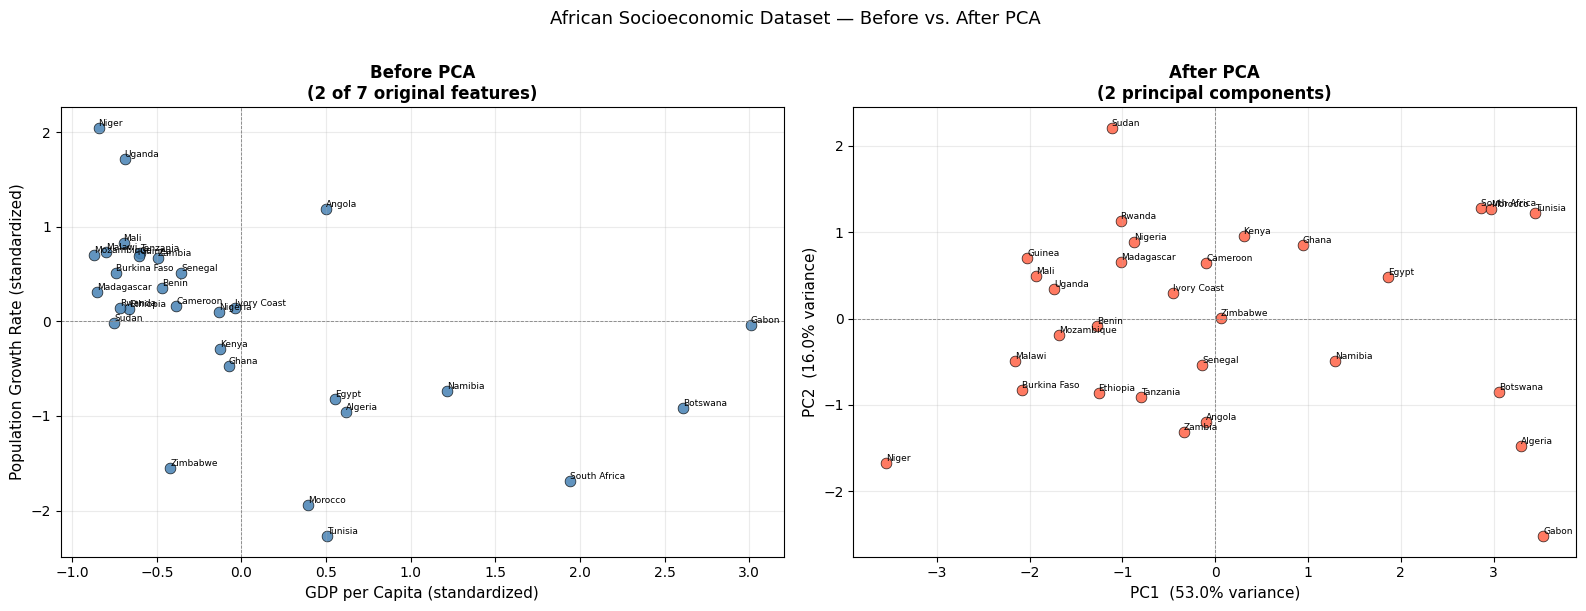

In [8]:
# Step 8: Visualize Before and After PCA
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Original data (first two features — GDP per capita vs. population growth) ---
ax1 = axes[0]
ax1.scatter(standardized_data[:, 0], standardized_data[:, 1],
            c='steelblue', edgecolors='k', linewidths=0.5, s=60, alpha=0.85)
for i, name in enumerate(country_names):
    ax1.annotate(name, (standardized_data[i, 0], standardized_data[i, 1]),
                 fontsize=6.5, ha='left', va='bottom')
ax1.set_xlabel('GDP per Capita (standardized)', fontsize=11)
ax1.set_ylabel('Population Growth Rate (standardized)', fontsize=11)
ax1.set_title('Before PCA\n(2 of 7 original features)', fontsize=12, fontweight='bold')
ax1.axhline(0, color='grey', lw=0.6, ls='--')
ax1.axvline(0, color='grey', lw=0.6, ls='--')
ax1.grid(True, alpha=0.25)

# --- Plot 2: Reduced data projected onto PC1 and PC2 ---
ax2 = axes[1]
ax2.scatter(reduced_data[:, 0], reduced_data[:, 1],
            c='tomato', edgecolors='k', linewidths=0.5, s=60, alpha=0.85)
for i, name in enumerate(country_names):
    ax2.annotate(name, (reduced_data[i, 0], reduced_data[i, 1]),
                 fontsize=6.5, ha='left', va='bottom')
ax2.set_xlabel(f'PC1  ({explained_variance_ratio[0]*100:.1f}% variance)', fontsize=11)
ax2.set_ylabel(f'PC2  ({explained_variance_ratio[1]*100:.1f}% variance)', fontsize=11)
ax2.set_title('After PCA\n(2 principal components)', fontsize=12, fontweight='bold')
ax2.axhline(0, color='grey', lw=0.6, ls='--')
ax2.axvline(0, color='grey', lw=0.6, ls='--')
ax2.grid(True, alpha=0.25)

plt.suptitle('African Socioeconomic Dataset — Before vs. After PCA', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('pca_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

**1. Interpreting the visualisation:**
Looking at the two plots, the Before PCA chart only uses two of the seven features we collected, so it misses a lot of what makes countries different from each other. After PCA, both axes combine information from all seven features together, which gives a much more complete picture in 2D. We can see that higher-income countries like South Africa, Botswana, Gabon and Namibia end up on one side of the PCA plot — they score high on GDP, electricity access and literacy at the same time. Countries like Niger, Mali and Burkina Faso sit on the opposite end. Some countries that looked close together in the original two-feature plot actually turn out to be quite different once all seven features are taken into account.

**2. Justification for choosing 2 principal components:**
We went with 2 principal components because together they explain about 69% of the total variance in the dataset, which we felt was a reasonable tradeoff. The main reason for picking 2 specifically is that it lets us plot the results in 2D and actually see what is going on visually. The tradeoff is that we are throwing away the variance explained by PC3 through PC7 — roughly 31% of the information — which includes subtler differences between countries that share similar scores but differ on things like agricultural land use. If we were building a predictive model rather than just visualising, we would probably keep 3 or 4 components to get above 85% explained variance.

**3. Information lost for this dataset (economic activity & population pressure):**
When we reduce from 7 dimensions down to 2, we lose the variance explained by PC3 to PC7. On the economic activity side, this means we lose detailed information about how agricultural land use interacts with electricity access — two features that together describe how far along a country is in its structural economic transition. On the population pressure side, we lose the ability to distinguish countries that have similar overall scores but very different urbanisation patterns — for instance, two countries might land in the same spot on the PCA plot but one could have rapid urban migration while the other has high natural population growth. These differences matter for policy analysis but are not visible in just 2 components.